In [45]:
# Импортируем библиотеки
import re
import nltk
from nltk.corpus import stopwords
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import pandas as pd
import pymorphy3
import spacy
from spacy import displacy
from sklearn.feature_extraction.text import TfidfVectorizer
import seaborn as sns
import networkx as nx
from nltk.collocations import BigramCollocationFinder, BigramAssocMeasures, TrigramCollocationFinder, TrigramAssocMeasures

# Скачать ресурсы nltk
nltk.download('punkt')
nltk.download('stopwords')

# Загрузка текста
with open("11.txt", "r", encoding="utf-8") as f:
    text = f.read()

print("Длина текста:", len(text))
print("Первые 500 символов:\n", text[:500])

Длина текста: 221136
Первые 500 символов:
 

Глава I.
ВСТУПИТЕЛЬНАЯ.

Начало трудно -- слышалъ я не разъ...
* * *

   Нѣсколько недѣль тому назадъ, одинъ гражданинъ Соединенныхъ Штатовъ, на собственной своей шкунѣ, отъ нечего дѣлать, направилъ путь изъ какого нибудь Коннектикута прямо въ Сѣверную Пальмиру. Въ тридцать-три дня окончилъ онъ свое путешествіе и бросилъ якорь противъ Англійской набережной. Напрасно спутники уговаривали его скорѣе выйти на берегъ и посмотрѣть хотя Невскій проспектъ. Угрюмый американецъ пообѣдалъ на своей шкунѣ


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\mikha\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mikha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [46]:
def normalize_old_russian_full(text):
    text = text.lower()
    replacements = {"ѣ":"е", "ъ":"", "ѳ":"ф", "і":"и", "ѵ":"и"}
    for k,v in replacements.items():
        text = text.replace(k,v)
    text = re.sub(r'[^а-яё\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text

# Очистка текста
text_clean = re.sub(r'\n+', ' ', text)
text_clean = re.sub(r'\s+', ' ', text_clean)

text_norm = normalize_old_russian_full(text_clean)

In [47]:
# Токенизация
tokens = nltk.word_tokenize(text_norm, language="russian")
print("Количество токенов:", len(tokens))
print("Первые 20 токенов:", tokens[:20])

# Лемматизация
morph = pymorphy3.MorphAnalyzer()
lemmas = [morph.parse(word)[0].normal_form for word in tokens if re.match(r'\w+', word)]

# Удаление стоп-слов
russian_stopwords = set(stopwords.words("russian"))
lemmas_no_stop = [lemma for lemma in lemmas if lemma not in russian_stopwords]

print("Количество лемм после очистки:", len(lemmas_no_stop))
print("Примеры лемм:", lemmas_no_stop[:20])

Количество токенов: 31822
Первые 20 токенов: ['глава', 'вступительная', 'начало', 'трудно', 'слышал', 'я', 'не', 'раз', 'несколько', 'недель', 'тому', 'назад', 'один', 'гражданин', 'соединенных', 'штатов', 'на', 'собственной', 'своей', 'шкуне']
Количество лемм после очистки: 19160
Примеры лемм: ['глава', 'вступительный', 'начало', 'трудно', 'слышать', 'несколько', 'неделя', 'назад', 'гражданин', 'соединить', 'штат', 'собственный', 'свой', 'шкун', 'нечего', 'делать', 'направить', 'путь', 'нибыть', 'коннектикут']


Топ-20 лемм: [('свой', 205), ('сказать', 187), ('всё', 165), ('это', 157), ('человек', 150), ('который', 141), ('мочь', 122), ('ещё', 104), ('наш', 102), ('весь', 102), ('говорить', 101), ('знать', 83), ('господин', 76), ('шайтан', 70), ('друг', 67), ('рука', 67), ('глаз', 58), ('заметить', 57), ('время', 54), ('хотеть', 52)]


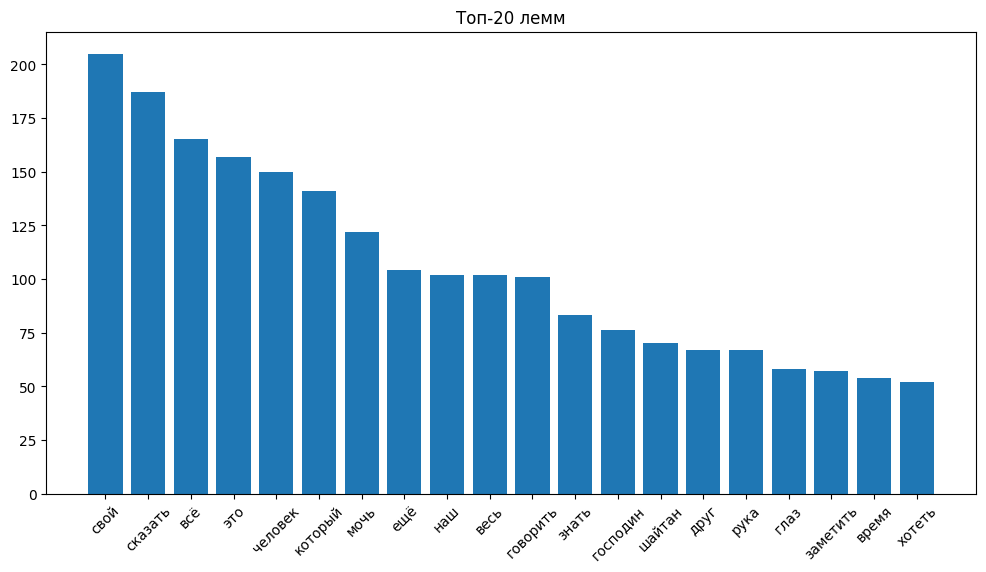

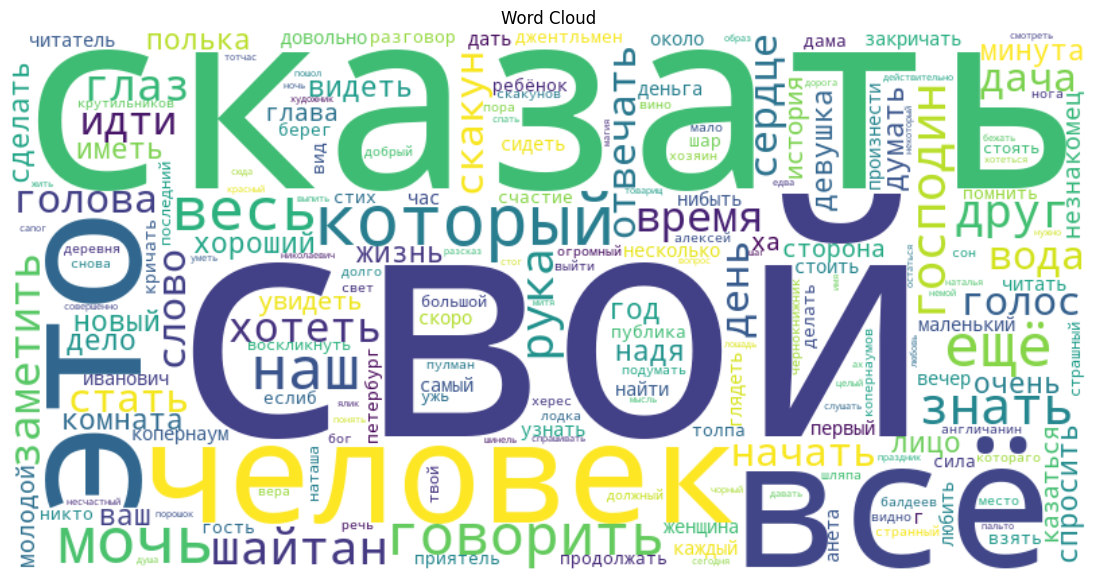

In [48]:
# Топ-20 лемм
freq = Counter(lemmas_no_stop)
top_words = freq.most_common(20)
print("Топ-20 лемм:", top_words)

# Гистограмма
words, counts = zip(*top_words)
plt.figure(figsize=(12,6))
plt.bar(words, counts)
plt.title("Топ-20 лемм")
plt.xticks(rotation=45)
plt.show()

# Word Cloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(freq)
plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud")
plt.show()

NOUN: 8295 (43.45%)
ADJF: 3084 (16.15%)
ADVB: 1268 (6.64%)
INFN: 5420 (28.39%)
NPRO: 60 (0.31%)
NUMR: 109 (0.57%)
PREP: 128 (0.67%)
CONJ: 141 (0.74%)
VERB: 26 (0.14%)
INTJ: 100 (0.52%)
PRCL: 405 (2.12%)
PRED: 37 (0.19%)
PRTF: 11 (0.06%)
ADJS: 5 (0.03%)
GRND: 2 (0.01%)
Времена глаголов: Counter({'past': 15, 'pres': 3})
Падежи существительных: Counter({'nomn': 6713, 'accs': 1231, 'gent': 262, 'ablt': 58, 'loct': 29, 'voct': 2})


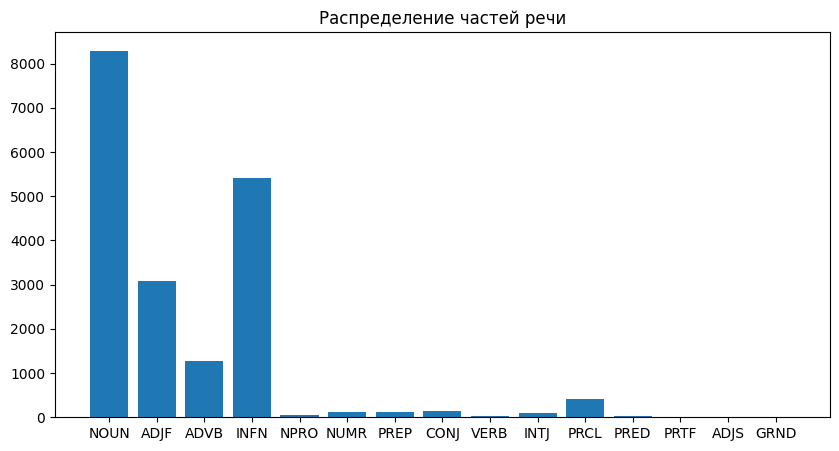

In [49]:
# Части речи
pos_tags = [morph.parse(word)[0].tag.POS for word in lemmas_no_stop if morph.parse(word)[0].tag.POS is not None]
pos_freq = Counter(pos_tags)
total = sum(pos_freq.values())
for k,v in pos_freq.items():
    print(f"{k}: {v} ({v/total:.2%})")

# Глаголы - времена
verbs = [morph.parse(word)[0] for word in lemmas_no_stop if morph.parse(word)[0].tag.POS == "VERB"]
tenses = Counter([v.tag.tense for v in verbs if v.tag.tense is not None])
print("Времена глаголов:", tenses)

# Существительные - падежи
nouns = [morph.parse(word)[0] for word in lemmas_no_stop if morph.parse(word)[0].tag.POS == "NOUN"]
cases = Counter([n.tag.case for n in nouns if n.tag.case is not None])
print("Падежи существительных:", cases)

# Визуализация POS
plt.figure(figsize=(10,5))
plt.bar(pos_freq.keys(), pos_freq.values())
plt.title("Распределение частей речи")
plt.show()

In [50]:
# Разделение на главы
chapters_raw = re.split(r'Глава\s+[IVXLCDM]+\.?', text_norm)

# Предобработка каждой главы
def preprocess_chapter(chapter):
    tokens = nltk.word_tokenize(chapter, language="russian")
    lemmas_ch = [morph.parse(word)[0].normal_form for word in tokens if re.match(r'\w+', word)]
    archaic_stopwords = ["в","с","он","как","к","из","мне","их","вот","был","нет","нас","все"]
    all_stopwords = set(stopwords.words("russian")) | set(archaic_stopwords)
    lemmas_clean = [w for w in lemmas_ch if w not in all_stopwords and len(w) > 2]
    return " ".join(lemmas_clean)

chapters = [preprocess_chapter(ch) for ch in chapters_raw if len(ch.strip()) > 0]

# TF-IDF
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(chapters)
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())
tfidf_df.head()

# Топ-10 слов первой главы
chapter_idx = 0
top_n = 10
chapter_tfidf = tfidf_df.iloc[chapter_idx]
top_words_chapter = chapter_tfidf.sort_values(ascending=False)[:top_n]
print("Топ-10 слов первой главы по TF-IDF:\n", top_words_chapter)

Топ-10 слов первой главы по TF-IDF:
 свой       0.306282
сказать    0.279389
всё        0.246520
это        0.234567
человек    0.224109
который    0.210662
мочь       0.182275
ещё        0.155382
весь       0.152394
наш        0.152394
Name: 0, dtype: float64


In [59]:
# Биграммы
bigram_measures = BigramAssocMeasures()
finder = BigramCollocationFinder.from_words(lemmas_no_stop)
top_bigrams = finder.nbest(bigram_measures.pmi, 20)
print("Топ-20 биграмм (коллокации):", top_bigrams)

# Триграммы (исправлено)
trigram_measures = TrigramAssocMeasures()
finder3 = TrigramCollocationFinder.from_words(lemmas_no_stop)
top_trigrams = finder3.nbest(trigram_measures.pmi, 20)
print("Топ-20 триграмм:", top_trigrams)

Топ-20 биграмм (коллокации): [('александрыч', 'виват'), ('алсксандрынский', 'театр'), ('аннушка', 'лиз'), ('антон', 'бенелоквант'), ('аплодисман', 'залиться'), ('апогей', 'кротко'), ('аптекарский', 'полюстров'), ('аптекарь', 'шулец'), ('ария', 'дуэт'), ('ахтереть', 'первеять'), ('бальзам', 'рана'), ('банка', 'помада'), ('баран', 'возить'), ('безвозвратно', 'петербургския'), ('бездыханный', 'безгласный'), ('беззащитный', 'отбросить'), ('безобразный', 'купол'), ('безошибочный', 'испорченнагой'), ('безпощадно', 'умерщвлять'), ('безсильный', 'беззащитный')]
Топ-20 триграмм: [('ария', 'дуэт', 'втянуть'), ('баран', 'возить', 'триумф'), ('безсильный', 'беззащитный', 'отбросить'), ('безсовестный', 'обман', 'образумить'), ('безчестно', 'тредьяковский', 'деидамия'), ('большаго', 'обобщение', 'раскрытие'), ('буйновидов', 'излишний', 'повсеместный'), ('валет', 'червь', 'приложить'), ('ввёртывать', 'чужое', 'словцо'), ('вдалеке', 'неподалёку', 'шептаться'), ('вдова', 'богатаго', 'негоциант'), ('вза

In [ ]:
# Берем оригинальный текст без склеивания строк
text_for_split = text  # НЕ text_clean и НЕ text_norm

# Нормализуем дореволюционные буквы
text_for_split = text_for_split.lower()
replacements = {"ѣ":"е", "ъ":"", "ѳ":"ф", "і":"и", "ѵ":"и"}
for k,v in replacements.items():
    text_for_split = text_for_split.replace(k,v)

# Заменяем многоточия, тире, звездочки на точку
text_for_split = text_for_split.replace("…", ".").replace("—", ".").replace("*", ".")


sentences = re.split(r'[.!?\n]+', text_for_split)

# Убираем пустые строки
sentences = [s.strip() for s in sentences if len(s.strip()) > 0]

# Длина предложений в словах
sent_lengths_words = [len([w for w in nltk.word_tokenize(sent) if w.isalpha()]) for sent in sentences]
avg_len_words = sum(sent_lengths_words)/len(sent_lengths_words)

print("Количество предложений:", len(sentences))
print("Средняя длина предложения (в словах):", round(avg_len_words,2))

Количество предложений: 3176
Средняя длина предложения (в словах): 9.9


Средняя длина выбранных предложений (в словах): 11.8


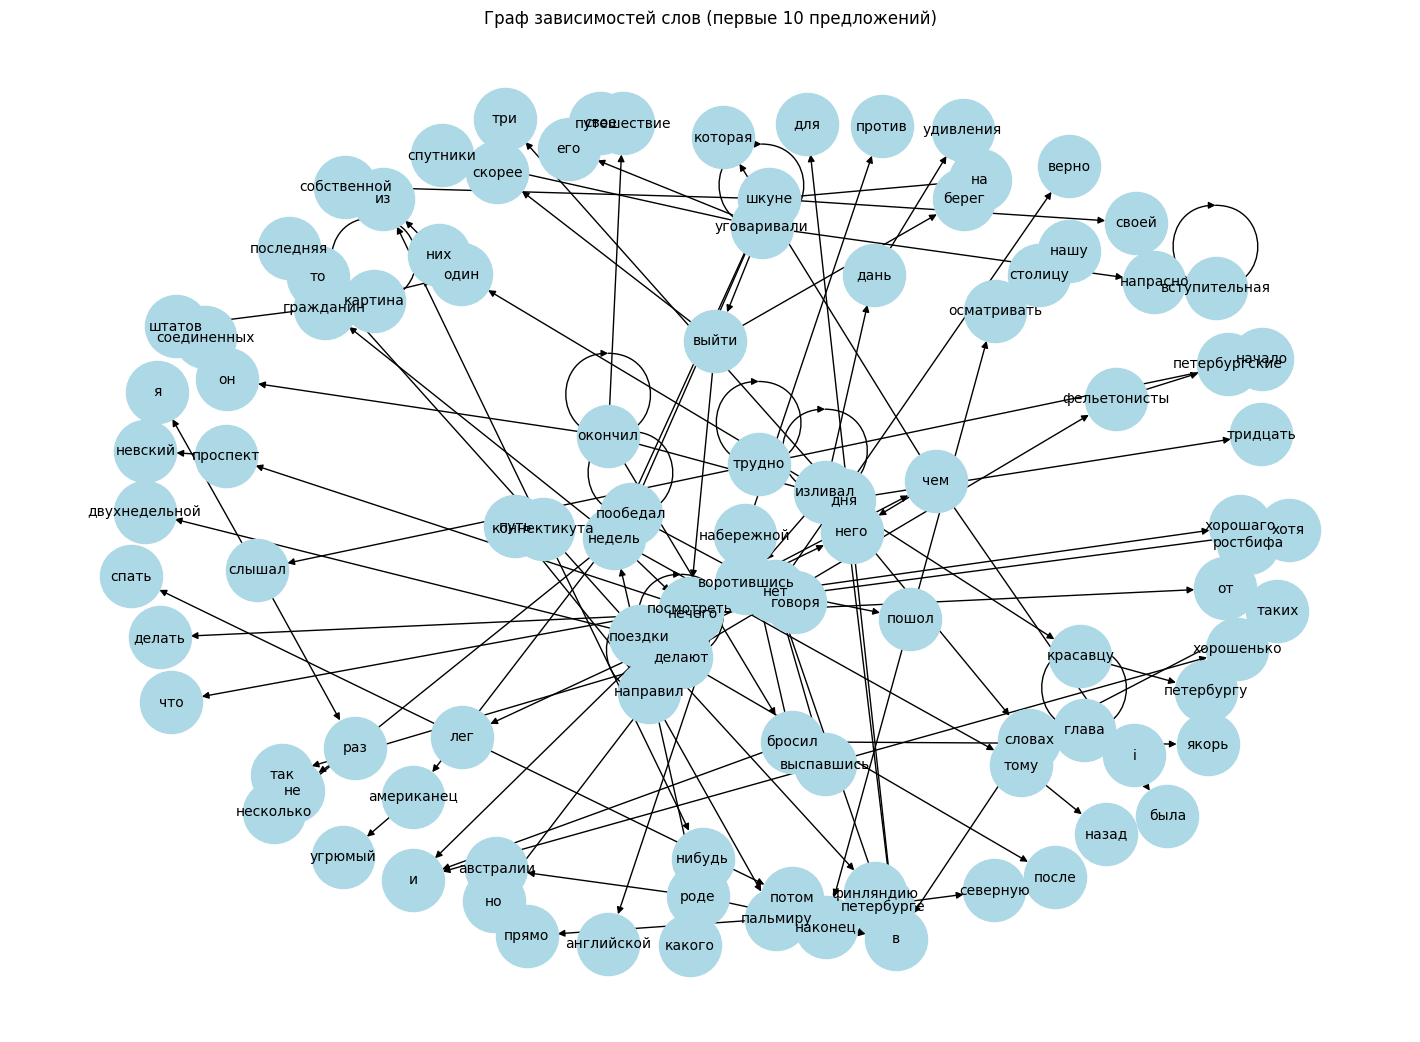

In [62]:
# Загружаем русскую модель spaCy
nlp = spacy.load("ru_core_news_sm")

# Выбираем первые 10 предложений для визуализации (чтобы графы были читаемы)
sample_sentences = sentences[:10]

# Средняя длина предложения в словах (подтверждаем)
sent_lengths_words = [len([w for w in nltk.word_tokenize(sent) if w.isalpha()]) for sent in sample_sentences]
avg_len_words = sum(sent_lengths_words)/len(sent_lengths_words)
print("Средняя длина выбранных предложений (в словах):", round(avg_len_words,2))

# Визуализация синтаксических деревьев первых 3 предложений
for sent_text in sample_sentences[:3]:
    doc_sent = nlp(sent_text)
    displacy.render(doc_sent, style="dep", jupyter=True)

# Создаем граф зависимостей для первых 10 предложений
G = nx.DiGraph()
for sent_text in sample_sentences:
    doc_sent = nlp(sent_text)
    for token in doc_sent:
        if token.dep_ != "punct" and token.is_alpha:
            G.add_edge(token.head.text, token.text)

# Визуализация графа зависимостей
plt.figure(figsize=(14,10))
nx.draw(G, with_labels=True, node_size=2000, node_color="lightblue", font_size=10, arrows=True)
plt.title("Граф зависимостей слов (первые 10 предложений)")
plt.show()

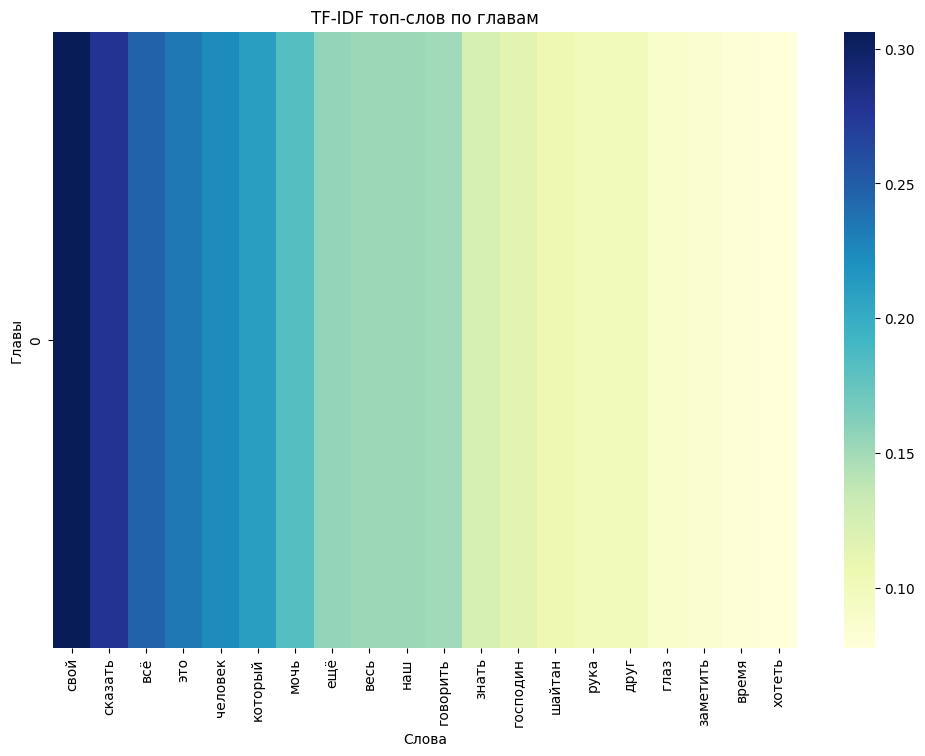

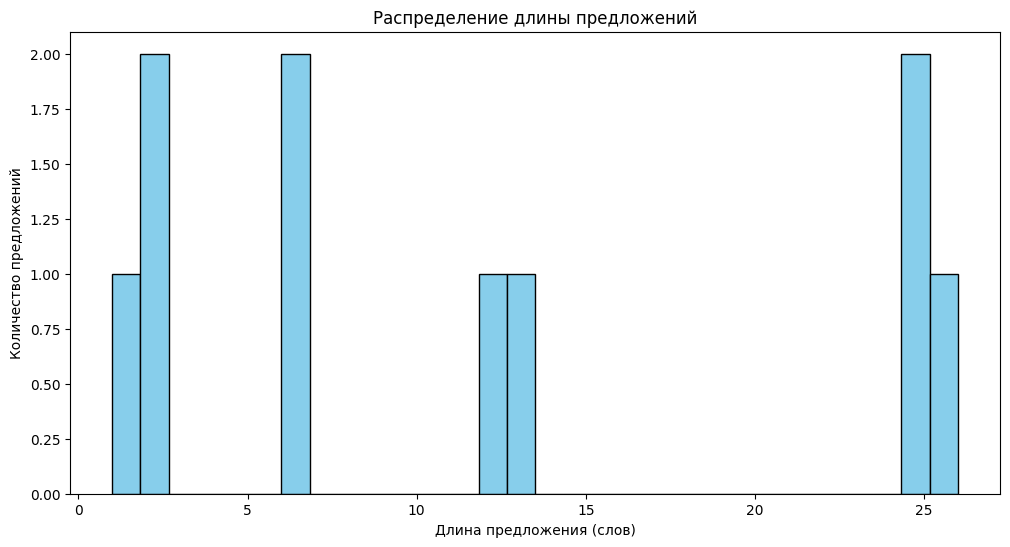

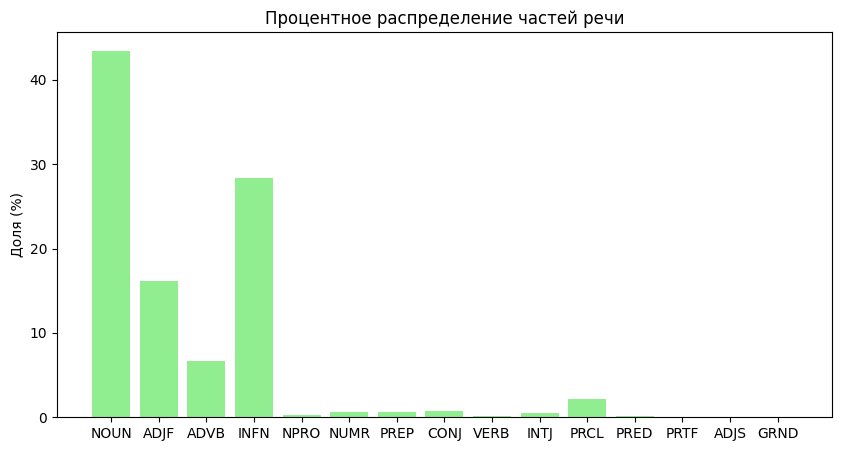

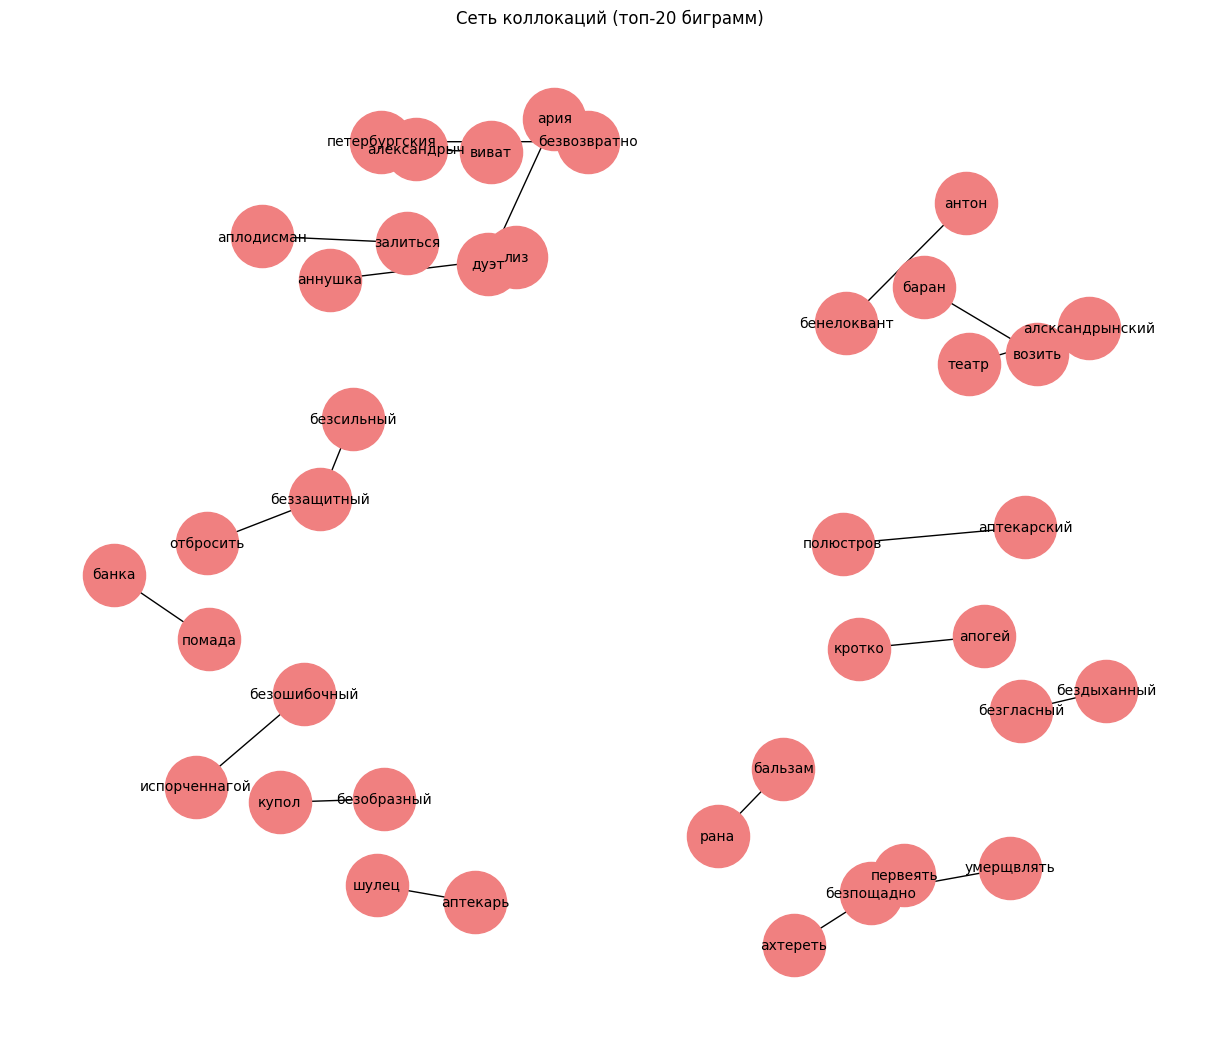

In [63]:
# 1️⃣ TF-IDF heatmap по топ-словам и главам
top_words_global = tfidf_df.sum().sort_values(ascending=False)[:20].index
plt.figure(figsize=(12,8))
sns.heatmap(tfidf_df[top_words_global], cmap="YlGnBu", annot=False)
plt.xlabel("Слова")
plt.ylabel("Главы")
plt.title("TF-IDF топ-слов по главам")
plt.show()

# 2️⃣ Гистограмма длины предложений
plt.figure(figsize=(12,6))
plt.hist(sent_lengths_words, bins=30, color='skyblue', edgecolor='black')
plt.xlabel("Длина предложения (слов)")
plt.ylabel("Количество предложений")
plt.title("Распределение длины предложений")
plt.show()

# 3️⃣ Процентное распределение частей речи
pos_percent = {k: v/total*100 for k,v in pos_freq.items()}
plt.figure(figsize=(10,5))
plt.bar(pos_percent.keys(), pos_percent.values(), color='lightgreen')
plt.ylabel("Доля (%)")
plt.title("Процентное распределение частей речи")
plt.show()

# 4️⃣ Сеть коллокаций (топ-20 биграмм)
G_colloc = nx.Graph()
for bigram in top_bigrams:
    G_colloc.add_edge(*bigram)

plt.figure(figsize=(12,10))
pos = nx.spring_layout(G_colloc, k=0.5)
nx.draw(G_colloc, pos, with_labels=True, node_size=2000, node_color="lightcoral", font_size=10)
plt.title("Сеть коллокаций (топ-20 биграмм)")
plt.show()

Интерпритация

Текст представляет собой роман, судя по всему, дореволюционной России. Ведется рассказ о путешествиях и наблюдениях за людьми и городом, а также о бытовых ситуациях (судя по леммам). В языке встречаются архаизмы и дореволюционная арфография, много существительных и глаголов. Средняя длинна предложений 10-12 слов, что делает текст достаточно легким для чтения, но при этом информативным. 

Применял ИИ для визуализции, TF-IDF, часть с Spacy 